# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [1]:
import torch
x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

# Calculate - See pages 100 - 104
mean = x.mean(dim=1, keepdim=True)
variance = x.var(dim=1, keepdim=True, unbiased=False)
normalized_output = (x - mean) / torch.sqrt(variance + 1e-5)

In [2]:
# Verify with
normalized_output.mean(dim=-1)
normalized_output.var(dim=-1, unbiased=False)

tensor([1.0000, 1.0000])

## Section 3: Exploring GELU
Compare ReLU and GELU

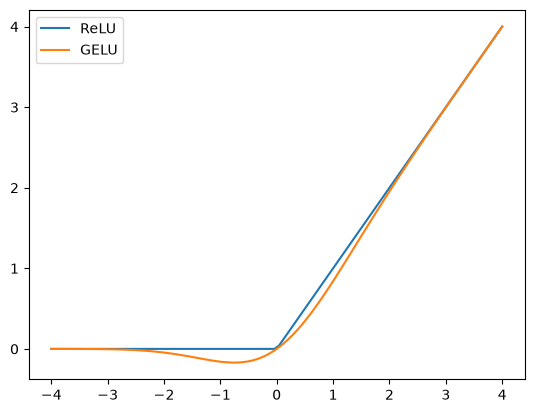

In [3]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use this and plot both
x_vals = torch.linspace(-4, 4, 100)
relu_vals = F.relu(x_vals)
gelu_vals = F.gelu(x_vals)

plt.plot(x_vals, relu_vals, label="ReLU")
plt.plot(x_vals, gelu_vals, label="GELU")
plt.legend()
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [4]:
import torch.nn as nn

# Create
input_shape = (2, 3, 768)
x = torch.randn(input_shape)

In [6]:
# Pass through 
#  Linear - Expect (2,3,768)
linear1 = nn.Linear(768, 3072)
out1 = linear1(x)
print(out1.shape)

#  GELU - Expect (2,3,3072)
gelu = nn.GELU()
out2 = gelu(out1)
print(out2.shape)

#  Linear again - Expect (2,3,768) again
linear2 = nn.Linear(3072, 768)
out3 = linear2(out2)
print(out3.shape)

torch.Size([2, 3, 3072])
torch.Size([2, 3, 3072])
torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [7]:
layer = nn.Linear(3, 3)
x = torch.randn(2, 3)

output_no_residual = layer(x)
output_with_residual = x + layer(x)

print (output_no_residual.shape)
print (output_with_residual.shape)

torch.Size([2, 3])
torch.Size([2, 3])


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output